# Multi-Antenna Wideband Digital Beamforming for CRES Electron Localisation

This notebook demonstrates wideband near-field delay-and-sum beamforming with
multiple dipole antennas observing a single CRES electron.  The beamformer
operates without prior knowledge of the electron's cyclotron frequency,
recovering both the spatial position and signal frequency from the data.

**Physical setup**: An 18.6 keV electron is trapped in a harmonic magnetic field.
The electron's guiding centre is displaced 3 cm from the z-axis.  The grad-B
drift causes this guiding centre to precess azimuthally around the trap axis.

**Antenna array**: Eight half-wave dipole antennas are arranged in a ring at
radius 10 cm from the z-axis in the $z = 0$ plane, evenly spaced in azimuth.
Each antenna's dipole axis is oriented along $\hat{z}$, coupling to the
$\hat{\theta}$-polarised cyclotron radiation.

**Beamforming**: The signals from all antennas are combined using wideband
delay-and-sum beamforming in the short-time Fourier transform (STFT) domain.
For each candidate position, frequency-dependent steering weights compensate
the differential propagation delay from the candidate to each antenna across
all frequency bins simultaneously.  This makes the beamformer agnostic to the
signal frequency — the electron is localised regardless of where its cyclotron
signal falls within the receiver bandwidth.

In [1]:
import numpy as np
import scipy.constants as sc
import scipy.fft
from scipy.signal import ShortTimeFFT
from scipy.signal.windows import hann
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

from CRESSignalStructure import (
    HarmonicField, Particle, TrajectoryGenerator,
    ReceiverChain, AntennaSignalGenerator, HalfWaveDipoleAntenna,
)

plt.rcParams['font.family'] = 'serif'

## Physical parameters

The trap is a single harmonic coil at $z = 0$ with 4 mT depth and 1 T background field.
The coil radius (15 cm) is larger than the antenna ring radius (10 cm) so that
the antennas sit inside the coil bore.

The electron starts 3 cm off-axis with a pitch angle of 89.9 degrees, giving
slow axial bounce and visible grad-B azimuthal precession.

In [2]:
# Trap parameters
TRAP_DEPTH = 4e-3                                # T
R_COIL     = 0.15                                # m (> antenna radius)
I_COIL     = 2 * TRAP_DEPTH * R_COIL / sc.mu_0  # A
B0         = 1.0                                 # T (background field)

# Particle parameters
KE          = 18.6e3                             # eV
PITCH_ANGLE = np.radians(89.9)
START_POS   = np.array([0.03, 0.0, 0.0])        # 3 cm off-axis in x

# Receiver parameters
ADC_RATE     = 1e9                               # Hz
LO_OFFSET    = 150e6                             # Hz (LO placed below f_c)
OVERSAMPLING = 5
TRAJ_RATE    = 10e9                              # Hz (must be > ADC_RATE * OVERSAMPLING)
T_ACQ        = 1e-3                              # s (1 ms)

# Antenna array parameters
N_ANTENNAS = 8
ANT_RADIUS = 0.10                               # m (10 cm from z-axis)
ANT_ANGLES = np.linspace(0, 2 * np.pi, N_ANTENNAS, endpoint=False)

In [3]:
field    = HarmonicField(R_COIL, I_COIL, B0)
particle = Particle(ke=KE, startPos=START_POS, pitchAngle=PITCH_ANGLE)

f_c = field.calc_omega_0(particle) / (2 * np.pi)
f_a = field.calc_omega_axial(particle) / (2 * np.pi)

print(f"Cyclotron frequency  : {f_c / 1e9:.4f} GHz")
print(f"Axial frequency      : {f_a / 1e6:.4f} MHz")
print(f"LO frequency         : {(f_c - LO_OFFSET) / 1e9:.4f} GHz")
print(f"Expected IF peak     : {LO_OFFSET / 1e6:.1f} MHz")

Cyclotron frequency  : 26.8980 GHz
Axial frequency      : 6.9954 MHz
LO frequency         : 26.7480 GHz
Expected IF peak     : 150.0 MHz


## Electron trajectory

The off-axis electron undergoes grad-B drift, causing its guiding centre to
precess in azimuth around the z-axis.  The plots below show the $x$-$y$
projection of the trajectory and the azimuthal angle of the guiding centre
as a function of time.

In [4]:
traj = TrajectoryGenerator(field, particle).generate(
    sample_rate=TRAJ_RATE, t_max=T_ACQ)

print(f"Trajectory: {traj.get_n_points()} samples, "
      f"{traj.get_duration() * 1e3:.1f} ms, "
      f"{traj.get_sample_rate() / 1e9:.1f} GHz sample rate")

Trajectory: 10000001 samples, 1.0 ms, 10.0 GHz sample rate


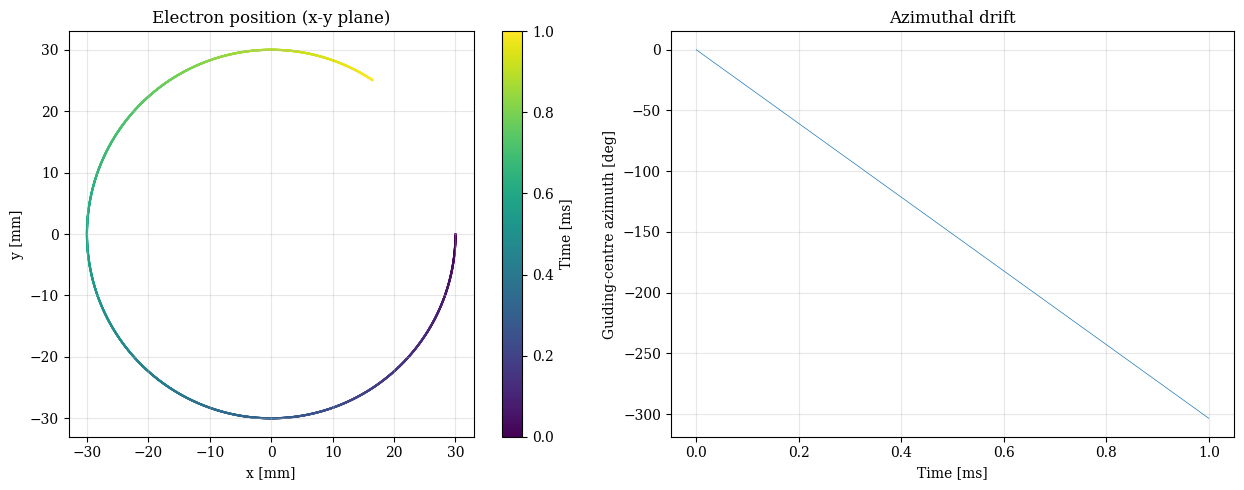

In [5]:
pos = traj.position

# The cyclotron radius (~0.5mm) is much smaller than the 3 cm offset,
# so the trajectory position is effectively the guiding-centre position.
phi_gc = np.unwrap(np.arctan2(pos[:, 1], pos[:, 0]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# x-y scatter coloured by time
skip = max(1, len(traj.time) // 5000)
sc_plot = axes[0].scatter(pos[::skip, 0] * 1e3, pos[::skip, 1] * 1e3,
                          c=traj.time[::skip] * 1e3, s=0.3, cmap='viridis')
axes[0].set_xlabel("x [mm]")
axes[0].set_ylabel("y [mm]")
axes[0].set_title("Electron position (x-y plane)")
axes[0].set_aspect('equal')
plt.colorbar(sc_plot, ax=axes[0], label="Time [ms]")
axes[0].grid(True, alpha=0.3)

# Azimuthal angle vs time
axes[1].plot(traj.time * 1e3, np.rad2deg(phi_gc), lw=0.5)
axes[1].set_xlabel("Time [ms]")
axes[1].set_ylabel("Guiding-centre azimuth [deg]")
axes[1].set_title("Azimuthal drift")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Antenna array

Eight half-wave dipole antennas are placed at 10 cm radius from the z-axis
in the $z = 0$ plane.  Each antenna's dipole axis is oriented along $\hat{z}$,
coupling to the $\hat{\theta}$-polarised cyclotron radiation arriving from
near the trap centre.

In [6]:
antennas = []
orientation = np.array([0.0, 0.0, 1.0])  # dipole axis along z

for i, angle in enumerate(ANT_ANGLES):
    pos = np.array([ANT_RADIUS * np.cos(angle),
                    ANT_RADIUS * np.sin(angle),
                    0.0])

    ant = HalfWaveDipoleAntenna(
        position=pos,
        orientation=orientation,
        resonant_frequency=f_c,
    )
    antennas.append(ant)
    print(f"Antenna {i}: pos=({pos[0]*1e3:+6.1f}, {pos[1]*1e3:+6.1f}, {pos[2]*1e3:+6.1f}) mm")

Antenna 0: pos=(+100.0,   +0.0,   +0.0) mm
Antenna 1: pos=( +70.7,  +70.7,   +0.0) mm
Antenna 2: pos=(  +0.0, +100.0,   +0.0) mm
Antenna 3: pos=( -70.7,  +70.7,   +0.0) mm
Antenna 4: pos=(-100.0,   +0.0,   +0.0) mm
Antenna 5: pos=( -70.7,  -70.7,   +0.0) mm
Antenna 6: pos=(  -0.0, -100.0,   +0.0) mm
Antenna 7: pos=( +70.7,  -70.7,   +0.0) mm


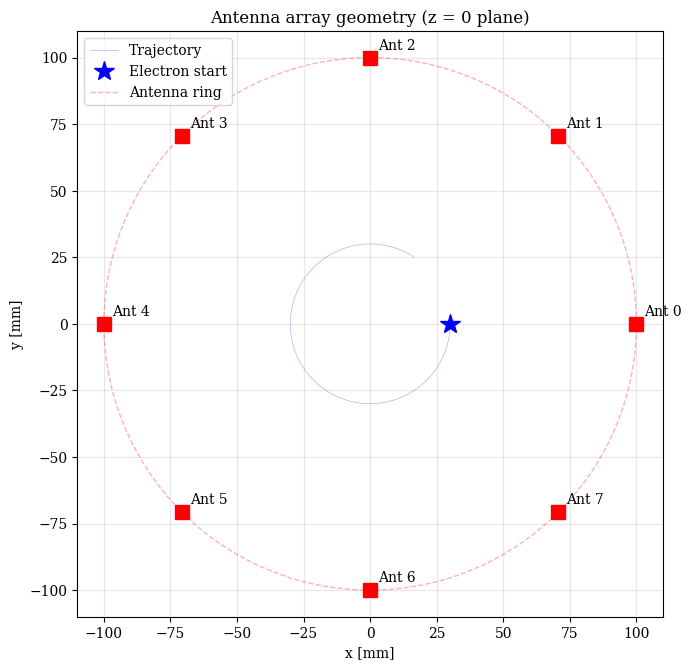

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))

# Antenna positions and dipole axis arrows
for i, ant in enumerate(antennas):
    p = ant.get_position()
    ax.plot(p[0] * 1e3, p[1] * 1e3, 'rs', ms=10)
    # Draw short z-axis arrow (projected as a dot, so show label instead)
    ax.text(p[0] * 1e3 + 3, p[1] * 1e3 + 3, f"Ant {i}", fontsize=10)

# Electron trajectory (downsampled)
skip = max(1, len(traj.time) // 3000)
ax.plot(traj.position[::skip, 0] * 1e3, traj.position[::skip, 1] * 1e3,
        'b-', alpha=0.3, lw=0.5, label="Trajectory")

# Start position
ax.plot(START_POS[0] * 1e3, START_POS[1] * 1e3, 'b*', ms=15,
        label="Electron start")

# Antenna ring
theta_ring = np.linspace(0, 2 * np.pi, 200)
ax.plot(ANT_RADIUS * np.cos(theta_ring) * 1e3,
        ANT_RADIUS * np.sin(theta_ring) * 1e3,
        'r--', alpha=0.3, lw=1, label="Antenna ring")

ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
ax.set_title("Antenna array geometry (z = 0 plane)")
ax.set_aspect('equal')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Signal generation

We generate the received signal at each antenna from the same electron
trajectory.  Each `AntennaSignalGenerator` computes the Lienard-Wiechert
electric field at the antenna location, projects it onto the antenna
effective length, then downmixes and digitises.

In [8]:
receiver = ReceiverChain(sample_rate=ADC_RATE, lo_frequency=f_c - LO_OFFSET)

signals = []
for i, ant in enumerate(antennas):
    print(f"Generating signal for antenna {i}...")
    gen = AntennaSignalGenerator(traj, ant, receiver, OVERSAMPLING)
    t_sig, sig = gen.generate_signal(return_time=True)
    signals.append(sig)
    print(f"  RMS voltage: {np.sqrt(np.mean(np.abs(sig)**2)):.2e} V")

n_sig = len(t_sig)
print(f"\nSignal: {n_sig} samples, {n_sig / ADC_RATE * 1e3:.2f} ms at "
      f"{ADC_RATE / 1e9:.0f} GHz")

Generating signal for antenna 0...
  RMS voltage: 9.96e-11 V
Generating signal for antenna 1...
  RMS voltage: 9.60e-11 V
Generating signal for antenna 2...
  RMS voltage: 1.11e-10 V
Generating signal for antenna 3...
  RMS voltage: 1.18e-10 V
Generating signal for antenna 4...
  RMS voltage: 1.20e-10 V
Generating signal for antenna 5...
  RMS voltage: 1.20e-10 V
Generating signal for antenna 6...
  RMS voltage: 1.19e-10 V
Generating signal for antenna 7...
  RMS voltage: 1.14e-10 V

Signal: 1000000 samples, 1.00 ms at 1 GHz


## Signal amplitude envelopes

Each antenna sees the same cyclotron radiation but with different amplitude
modulation as the electron's guiding centre drifts around the ring.  When the
electron is nearest to a particular antenna, that antenna receives the
strongest signal.

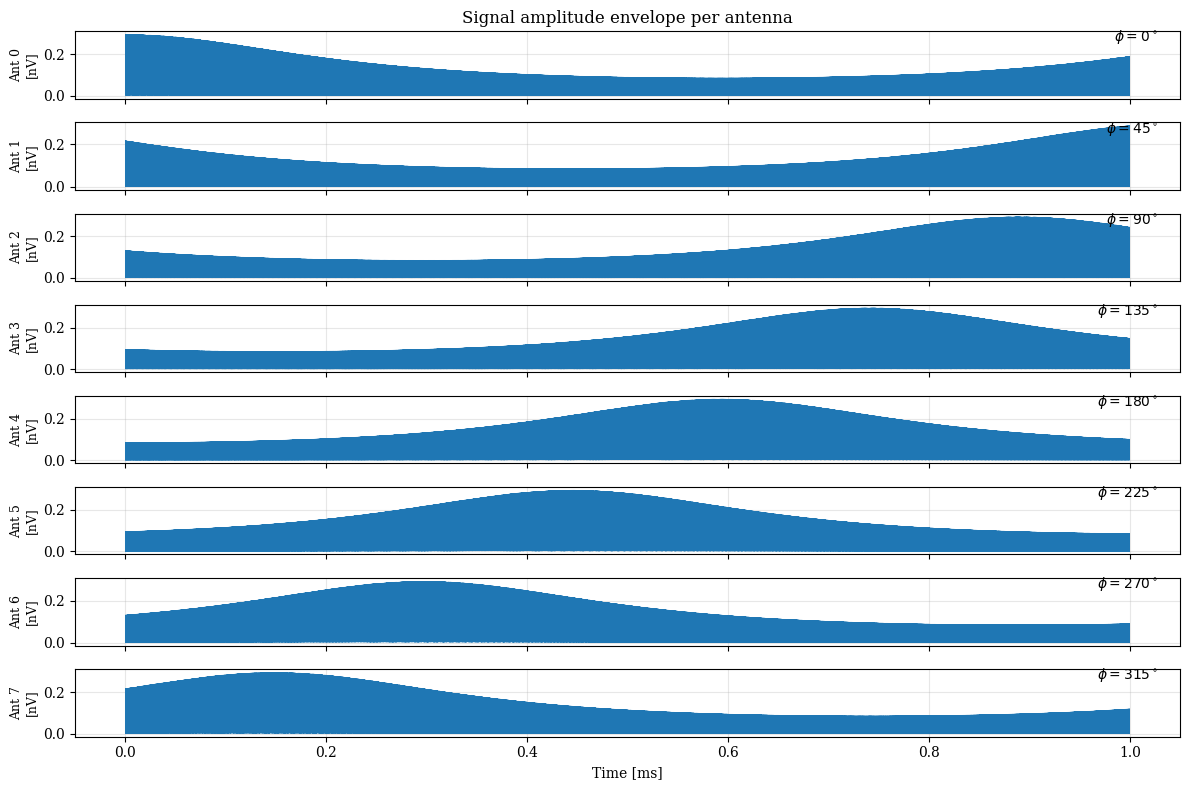

In [9]:
fig, axes = plt.subplots(N_ANTENNAS, 1, figsize=(12, 8), sharex=True)

for i, sig in enumerate(signals):
    envelope = np.abs(sig)
    axes[i].plot(t_sig * 1e3, envelope * 1e9, lw=0.3)
    axes[i].set_ylabel(f"Ant {i}\n[nV]", fontsize=9)
    axes[i].grid(True, alpha=0.3)

    angle_deg = np.rad2deg(ANT_ANGLES[i])
    axes[i].text(0.98, 0.85, fr"$\phi = {angle_deg:.0f}^\circ$",
                 transform=axes[i].transAxes, ha='right', fontsize=10)

axes[-1].set_xlabel("Time [ms]")
axes[0].set_title("Signal amplitude envelope per antenna")
plt.tight_layout()
plt.show()

## Wideband delay-and-sum beamforming

### Approach

The beamformer operates in the short-time Fourier transform (STFT) domain.
For each time window $t_k$, we have the full complex spectrum $S_i(f, t_k)$
from each antenna $i$.

For a candidate electron position $(x, y)$ in the transverse plane, the
steering weight for antenna $i$ at frequency bin $f$ is:

$$w_i(f, x, y) = \exp\!\left(+j\left[\frac{2\pi (f_\mathrm{LO} + f)}{c}\,R_i(x,y) \;+\; \theta_i^{\mathrm{ant}} - \theta^{\mathrm{cand}}(x,y)\right]\right)$$

where $R_i(x, y) = |\mathbf{r}_\mathrm{ant}^{(i)} - \mathbf{r}_\mathrm{cand}|$
is the distance from the candidate position to antenna $i$, and $f_\mathrm{LO}$
is the local oscillator frequency used in the receiver chain.  The angular
term $\theta_i^{\mathrm{ant}} - \theta^{\mathrm{cand}}$ corrects for the
cyclotron-orbit phase (see
[Ashtari Esfahani et al. (2024)](), Eq. 2.4).

The steering weight factorises as $w_i = w_i^{\mathrm{base}} \cdot
\exp(+j\,2\pi f\,\tau_i)$, where $w_i^{\mathrm{base}}$ handles the
LO-frequency phase and angular correction (both frequency-independent), and
the exponential handles the frequency-dependent propagation delay
$\tau_i = R_i / c$.

Crucially, **$f_c$ does not appear** in the steering weights — only
$f_\mathrm{LO}$ (known from the receiver) and $f$ (the STFT bin frequencies).
The beamformer does not need to know the cyclotron frequency.

The beamformed power at $(x, y, t_k)$ is:

$$P(x, y, t_k) = \sum_f \left|\sum_{i} w_i(f, x, y)\,S_i(f, t_k)\right|^2$$

The maximum of $P$ over the $(x,y)$ grid gives the estimated electron position
at each time step, and the beamformed spectrum at the peak position reveals the
signal frequency.

In [10]:
# STFT parameters
NPERSEG = 2048
HOP     = NPERSEG // 2

win = hann(NPERSEG)
SFT = ShortTimeFFT(win, hop=HOP, fs=ADC_RATE, fft_mode='centered')

freqs  = SFT.f
t_stft = SFT.t(n_sig)
n_freq = len(freqs)

# Keep only positive-frequency bins (signal lives here for complex baseband)
pos_idx   = np.arange(n_freq // 2, n_freq)
freqs_pos = freqs[pos_idx]

stft_list = []
for sig in signals:
    Zxx = SFT.stft(sig)
    stft_list.append(Zxx[pos_idx, :])

# Stack: shape (N_ANTENNAS, n_freq_pos, n_time_steps)
stft_pos = np.array(stft_list)
n_freq_pos = stft_pos.shape[1]

print(f"STFT: {n_freq_pos} positive freq bins, {len(t_stft)} time steps")
print(f"Freq range: {freqs_pos[0]/1e6:.1f} to {freqs_pos[-1]/1e6:.1f} MHz")
print(f"STFT data: {stft_pos.nbytes / 1e6:.0f} MB")

STFT: 1024 positive freq bins, 978 time steps
Freq range: 0.0 to 499.5 MHz
STFT data: 128 MB


In [11]:
# Beamforming grid in the x-y plane
GRID_HALF_SIZE = 0.05   # m (50 mm — covers the 3 cm offset with margin)
N_GRID         = 51

x_grid = np.linspace(-GRID_HALF_SIZE, GRID_HALF_SIZE, N_GRID)
y_grid = np.linspace(-GRID_HALF_SIZE, GRID_HALF_SIZE, N_GRID)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)

# Antenna positions in the x-y plane: shape (N_ANTENNAS, 2)
ant_pos_xy = np.array([[ant.get_position()[0], ant.get_position()[1]]
                        for ant in antennas])

# Distance from each grid point to each antenna: shape (N_GRID, N_GRID, N_ANTENNAS)
R_grid = np.zeros((N_GRID, N_GRID, N_ANTENNAS))
for i in range(N_ANTENNAS):
    dx = X_grid - ant_pos_xy[i, 0]
    dy = Y_grid - ant_pos_xy[i, 1]
    R_grid[:, :, i] = np.sqrt(dx**2 + dy**2)

# Angular separation (cyclotron orbit phase correction)
theta_ant  = np.arctan2(ant_pos_xy[:, 1], ant_pos_xy[:, 0])
theta_cand = np.arctan2(Y_grid, X_grid)

theta_sep = np.zeros((N_GRID, N_GRID, N_ANTENNAS))
for i in range(N_ANTENNAS):
    theta_sep[:, :, i] = theta_ant[i] - theta_cand

# Wideband steering weights
# Use f_LO (not f_c) — the beamformer does not need to know f_c
f_LO    = receiver.get_lo_frequency()
tau_grid = R_grid / sc.c  # propagation delays

# Base phase: propagation at LO frequency + angular correction (freq-independent)
W_base = np.exp(1j * (2 * np.pi * f_LO * tau_grid + theta_sep))

# Frequency-dependent delay phase
delay_phase = np.exp(
    1j * 2 * np.pi
    * freqs_pos[np.newaxis, np.newaxis, np.newaxis, :]
    * tau_grid[:, :, :, np.newaxis]
)

# Full steering matrix in complex64 for speed and memory
W_full = (W_base[:, :, :, np.newaxis] * delay_phase).astype(np.complex64)
W_full = W_full.reshape(N_GRID * N_GRID, N_ANTENNAS, n_freq_pos)
print(f"Steering matrix: {W_full.nbytes / 1e6:.0f} MB")

# Beamform over all time steps
n_time = stft_pos.shape[2]
P_beam = np.zeros((N_GRID, N_GRID, n_time))
peak_spectra = np.zeros((n_time, n_freq_pos))

for k in range(n_time):
    S_k = stft_pos[:, :, k].astype(np.complex64)  # (N_ANTENNAS, n_freq_pos)
    beamformed = np.einsum('gaf,af->gf', W_full, S_k)
    power_spectrum = np.abs(beamformed)**2
    P_flat = np.sum(power_spectrum, axis=1)
    P_beam[:, :, k] = P_flat.reshape(N_GRID, N_GRID)

    peak_flat = np.argmax(P_flat)
    peak_spectra[k] = power_spectrum[peak_flat]

    if k % 500 == 0 or k == n_time - 1:
        print(f"  Step {k+1}/{n_time}")

# Peak position at each time step
peak_idx = np.array([np.unravel_index(np.argmax(P_beam[:, :, k]),
                                       (N_GRID, N_GRID))
                      for k in range(n_time)])
x_est = x_grid[peak_idx[:, 1]]  # column index -> x
y_est = y_grid[peak_idx[:, 0]]  # row index -> y

print(f"Beamforming complete: {n_time} time steps, {N_GRID}x{N_GRID} grid")

Steering matrix: 170 MB
  Step 1/978
  Step 501/978
  Step 978/978
Beamforming complete: 978 time steps, 51x51 grid


## Beamformed power maps

The 2D power maps below show the estimated electron position at several
time snapshots.  The true guiding-centre position (from the trajectory)
is overlaid as a white cross for comparison.

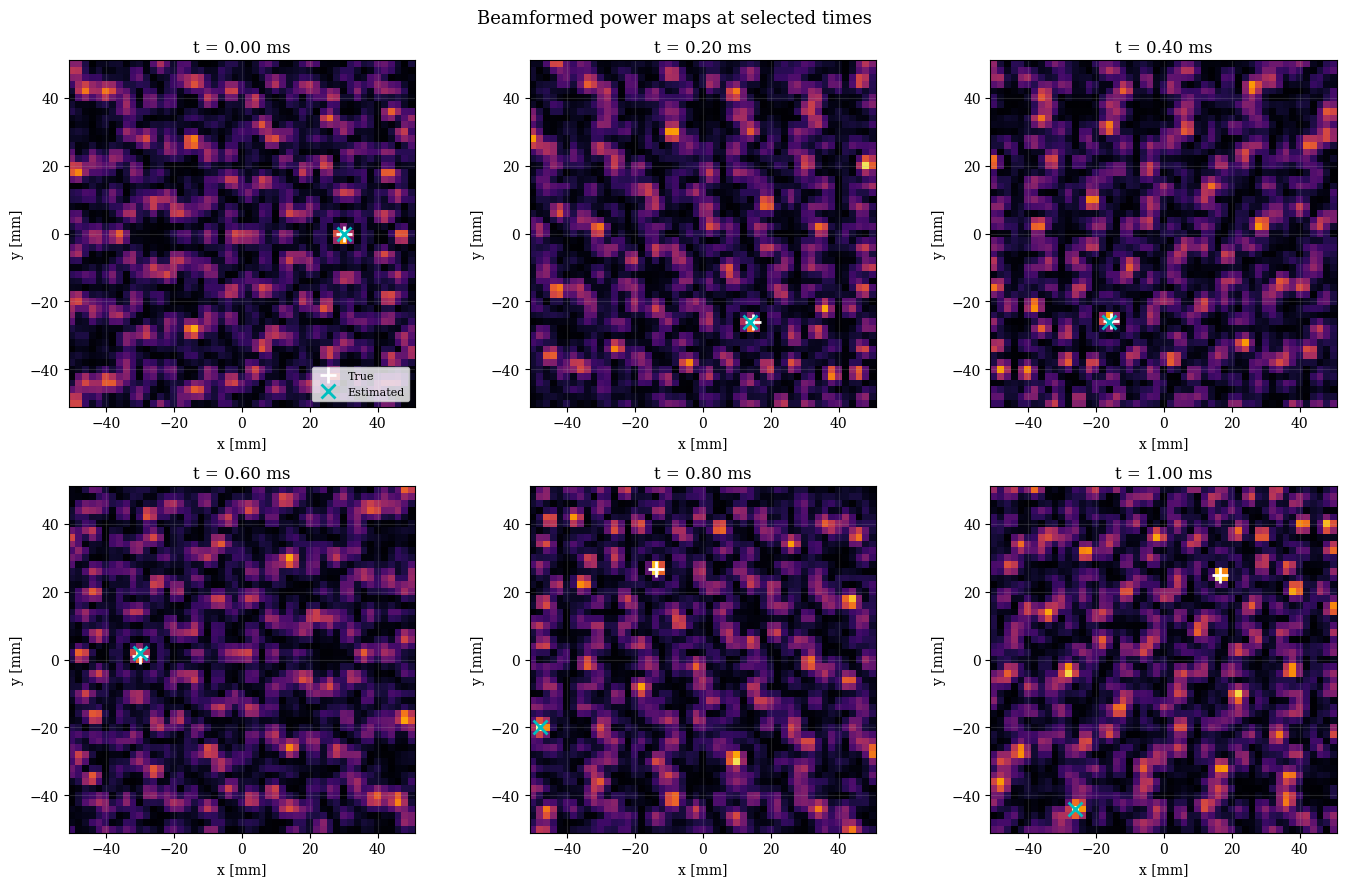

In [12]:
# Interpolate true trajectory position to STFT centre times
x_true_fn = interp1d(traj.time, traj.position[:, 0], kind='linear',
                      bounds_error=False, fill_value='extrapolate')
y_true_fn = interp1d(traj.time, traj.position[:, 1], kind='linear',
                      bounds_error=False, fill_value='extrapolate')

x_true = x_true_fn(t_stft)
y_true = y_true_fn(t_stft)

# Select 6 evenly-spaced time snapshots
n_show   = 6
show_idx = np.linspace(0, n_time - 1, n_show, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.ravel()

for ax_i, k in enumerate(show_idx):
    ax = axes[ax_i]
    im = ax.pcolormesh(x_grid * 1e3, y_grid * 1e3, P_beam[:, :, k],
                        cmap='inferno', shading='auto')
    ax.plot(x_true[k] * 1e3, y_true[k] * 1e3, 'w+', ms=12, mew=2,
            label="True")
    ax.plot(x_est[k] * 1e3, y_est[k] * 1e3, 'cx', ms=10, mew=2,
            label="Estimated")
    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]")
    ax.set_title(f"t = {t_stft[k] * 1e3:.2f} ms")
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    if ax_i == 0:
        ax.legend(fontsize=8, loc='lower right')

plt.suptitle("Beamformed power maps at selected times", fontsize=13)
plt.tight_layout()
plt.show()

### Beamformed spectrum at estimated position

The wideband beamformer naturally recovers the signal frequency.  The plots
below show the beamformed power spectrum at the estimated electron position
for several time snapshots.  The peak frequency corresponds to the IF
frequency of the cyclotron signal — recovered without prior knowledge of
$f_c$.

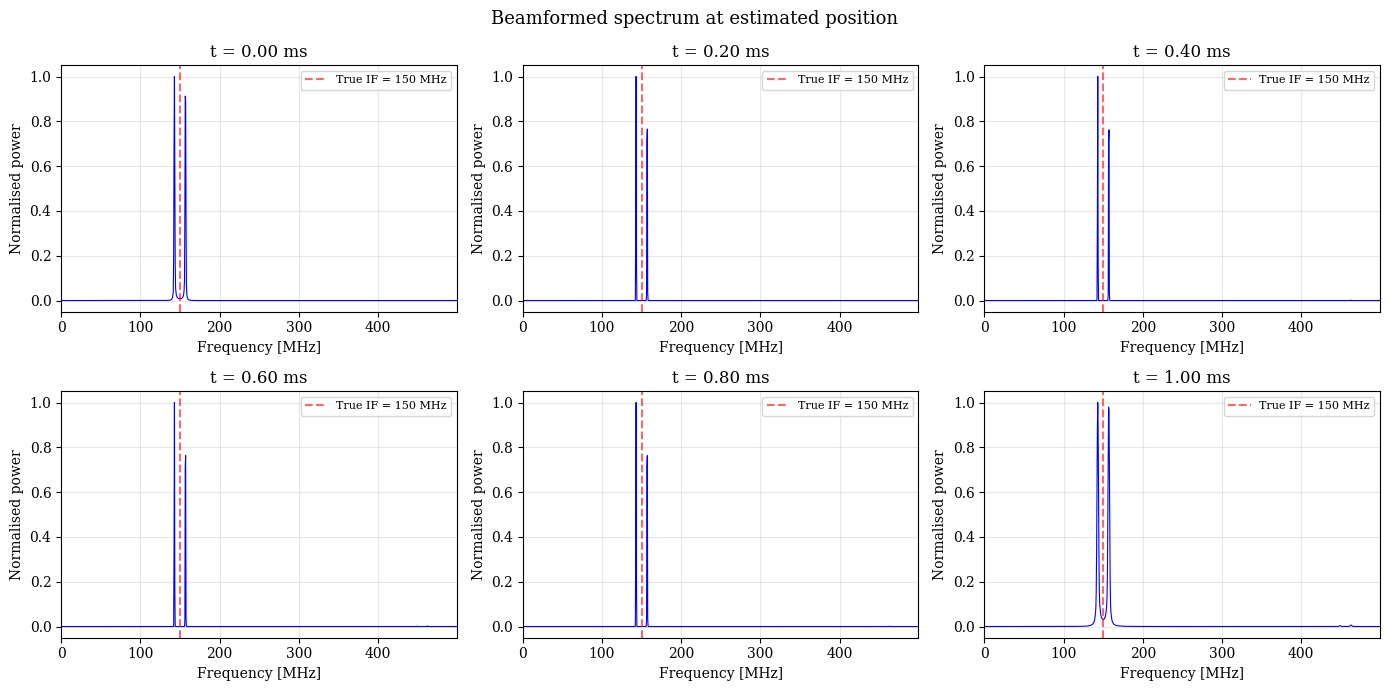

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for ax_i, k in enumerate(show_idx):
    ax = axes.ravel()[ax_i]
    spec_norm = peak_spectra[k] / np.max(peak_spectra[k])
    ax.plot(freqs_pos / 1e6, spec_norm, 'b-', lw=0.8)
    ax.axvline(LO_OFFSET / 1e6, color='r', ls='--', alpha=0.6,
               label=f"True IF = {LO_OFFSET/1e6:.0f} MHz")
    ax.set_xlabel("Frequency [MHz]")
    ax.set_ylabel("Normalised power")
    ax.set_title(f"t = {t_stft[k]*1e3:.2f} ms")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(freqs_pos[0] / 1e6, freqs_pos[-1] / 1e6)

plt.suptitle("Beamformed spectrum at estimated position", fontsize=13)
plt.tight_layout()
plt.show()

## Position tracking: estimated vs true

The beamformer's estimated position is compared to the true guiding-centre
position as a function of time.  We show both the azimuthal angle and the
radial distance from the z-axis.

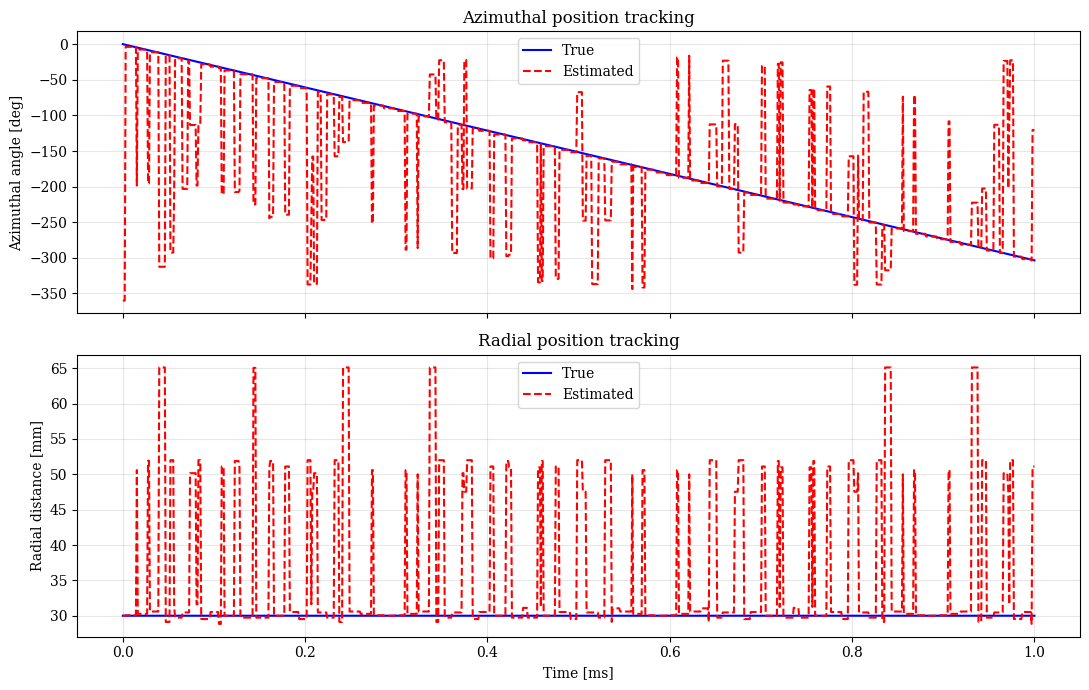

In [18]:
phi_true = np.unwrap(np.arctan2(y_true, x_true))
phi_est  = np.unwrap(np.arctan2(y_est, x_est))

for i, phi in enumerate(phi_est):
    while phi >= 0.0:
        phi -= 2 * np.pi
    
    phi_est[i] = phi

r_true = np.sqrt(x_true**2 + y_true**2)
r_est  = np.sqrt(x_est**2 + y_est**2)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(t_stft * 1e3, np.rad2deg(phi_true), 'b-', lw=1.5, label="True")
axes[0].plot(t_stft * 1e3, np.rad2deg(phi_est), 'r--', lw=1.5, label="Estimated")
axes[0].set_ylabel("Azimuthal angle [deg]")
axes[0].set_title("Azimuthal position tracking")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_stft * 1e3, r_true * 1e3, 'b-', lw=1.5, label="True")
axes[1].plot(t_stft * 1e3, r_est * 1e3, 'r--', lw=1.5, label="Estimated")
axes[1].set_xlabel("Time [ms]")
axes[1].set_ylabel("Radial distance [mm]")
axes[1].set_title("Radial position tracking")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Drift visualisation

The estimated position trace in the $x$-$y$ plane is overlaid on the true
guiding-centre trajectory, showing how the beamformer tracks the azimuthal
precession.

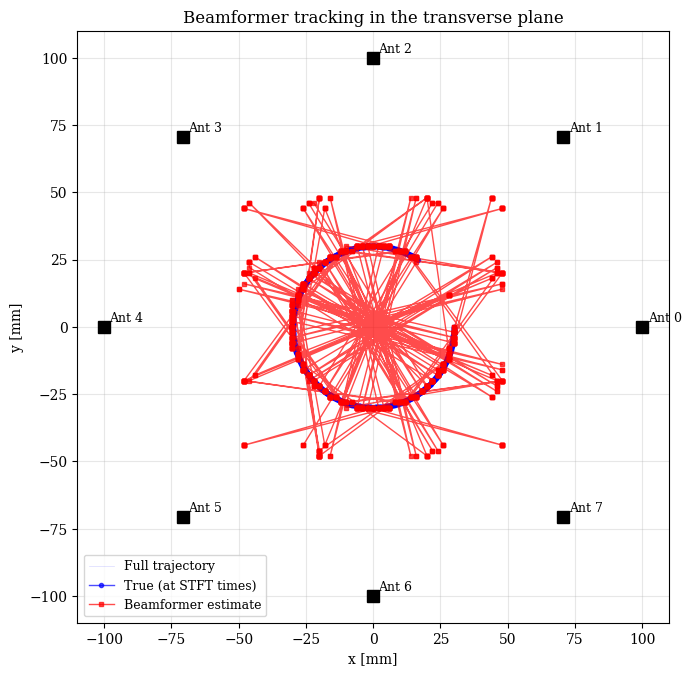

In [15]:
fig, ax = plt.subplots(figsize=(7, 7))

# Full trajectory (downsampled)
skip = max(1, len(traj.time) // 3000)
ax.plot(traj.position[::skip, 0] * 1e3, traj.position[::skip, 1] * 1e3,
        'b-', alpha=0.15, lw=0.5, label="Full trajectory")

# True guiding-centre at STFT times
ax.plot(x_true * 1e3, y_true * 1e3, 'b-o', ms=3, lw=1, alpha=0.7,
        label="True (at STFT times)")

# Beamformer estimates
ax.plot(x_est * 1e3, y_est * 1e3, 'r-s', ms=3, lw=1, alpha=0.7,
        label="Beamformer estimate")

# Antenna positions
for i, ant in enumerate(antennas):
    p = ant.get_position()
    ax.plot(p[0] * 1e3, p[1] * 1e3, 'ks', ms=8)
    ax.text(p[0] * 1e3 + 2, p[1] * 1e3 + 2, f"Ant {i}", fontsize=9)

ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
ax.set_title("Beamformer tracking in the transverse plane")
ax.set_aspect('equal')
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Frequency-agnostic demonstration: shifted LO

To verify that the beamformer works independently of the signal frequency,
we simulate a different LO offset by applying a frequency shift to the
existing signals in post-processing.  Multiplying each complex baseband signal
by $\exp(+j\,2\pi\,\Delta f\,t)$ shifts the IF by $+\Delta f$, which is
mathematically equivalent to having used a lower LO frequency.

The steering matrix $W$ does not change — the same matrix correctly steers
at all RF frequencies across the band.  The signal simply appears in a
different STFT bin.

In [16]:
DELTA_F = 50e6  # Hz — shift IF from 150 MHz to 200 MHz

# Frequency-shift the existing signals
shift_phasor = np.exp(1j * 2 * np.pi * DELTA_F * t_sig)
signals_shifted = [sig * shift_phasor for sig in signals]

# Compute STFT of shifted signals (positive frequencies only)
stft_shifted_list = []
for sig in signals_shifted:
    Zxx = SFT.stft(sig)
    stft_shifted_list.append(Zxx[pos_idx, :])

stft_shifted = np.array(stft_shifted_list)

# Beamform with the SAME steering matrix
n_time_s = stft_shifted.shape[2]
P_beam_s = np.zeros((N_GRID, N_GRID, n_time_s))
peak_spectra_s = np.zeros((n_time_s, n_freq_pos))

print(f"Re-beamforming with IF shifted by +{DELTA_F/1e6:.0f} MHz ...")
for k in range(n_time_s):
    S_k = stft_shifted[:, :, k].astype(np.complex64)
    beamformed = np.einsum('gaf,af->gf', W_full, S_k)
    power_spectrum = np.abs(beamformed)**2
    P_flat = np.sum(power_spectrum, axis=1)
    P_beam_s[:, :, k] = P_flat.reshape(N_GRID, N_GRID)

    peak_flat = np.argmax(P_flat)
    peak_spectra_s[k] = power_spectrum[peak_flat]

    if k % 500 == 0 or k == n_time_s - 1:
        print(f"  Step {k+1}/{n_time_s}")

peak_idx_s = np.array([np.unravel_index(np.argmax(P_beam_s[:, :, k]),
                                         (N_GRID, N_GRID))
                        for k in range(n_time_s)])
x_est_s = x_grid[peak_idx_s[:, 1]]
y_est_s = y_grid[peak_idx_s[:, 0]]

print("Done.")

Re-beamforming with IF shifted by +50 MHz ...
  Step 1/978
  Step 501/978
  Step 978/978
Done.


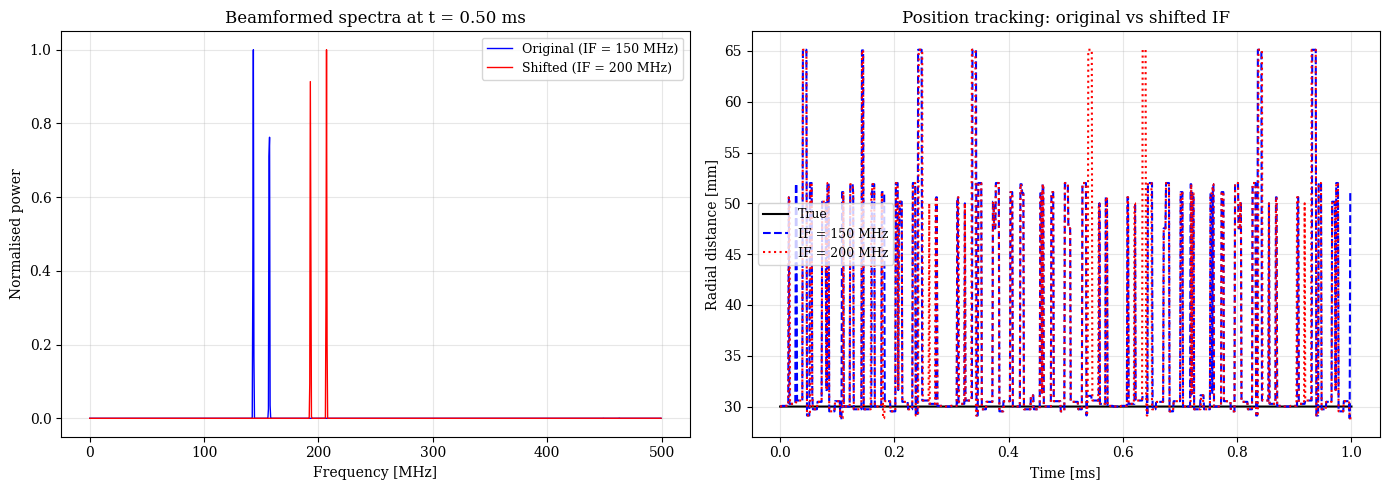

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: beamformed spectra comparison at one time snapshot
k_mid = n_time // 2
spec_orig = peak_spectra[k_mid] / np.max(peak_spectra[k_mid])
spec_shift = peak_spectra_s[k_mid] / np.max(peak_spectra_s[k_mid])

axes[0].plot(freqs_pos / 1e6, spec_orig, 'b-', lw=1,
             label=f"Original (IF = {LO_OFFSET/1e6:.0f} MHz)")
axes[0].plot(freqs_pos / 1e6, spec_shift, 'r-', lw=1,
             label=f"Shifted (IF = {(LO_OFFSET + DELTA_F)/1e6:.0f} MHz)")
axes[0].set_xlabel("Frequency [MHz]")
axes[0].set_ylabel("Normalised power")
axes[0].set_title(f"Beamformed spectra at t = {t_stft[k_mid]*1e3:.2f} ms")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: radial position tracking comparison
r_est_s = np.sqrt(x_est_s**2 + y_est_s**2)
axes[1].plot(t_stft * 1e3, r_true * 1e3, 'k-', lw=1.5, label="True")
axes[1].plot(t_stft * 1e3, r_est * 1e3, 'b--', lw=1.5,
             label=f"IF = {LO_OFFSET/1e6:.0f} MHz")
axes[1].plot(t_stft[:n_time_s] * 1e3, r_est_s * 1e3, 'r:', lw=1.5,
             label=f"IF = {(LO_OFFSET + DELTA_F)/1e6:.0f} MHz")
axes[1].set_xlabel("Time [ms]")
axes[1].set_ylabel("Radial distance [mm]")
axes[1].set_title("Position tracking: original vs shifted IF")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated wideband near-field delay-and-sum beamforming with
eight half-wave dipole antennas observing a single CRES electron.

Key findings:

- **Frequency-agnostic localisation**: the wideband beamformer localises the
  electron without prior knowledge of the cyclotron frequency.  The steering
  weights depend only on the LO frequency and array geometry, not on $f_c$.
- **Frequency recovery**: the beamformed spectrum at the estimated position
  reveals the IF frequency as a byproduct of the localisation.
- **Amplitude modulation**: the grad-B drift causes each antenna to see a
  time-varying signal amplitude as the electron precesses past it, with the
  peak amplitude occurring when the electron is nearest.
- **Azimuthal and radial tracking**: the beamformer tracks both the azimuthal
  precession and the radial distance of the electron's guiding centre.
- **Robustness to IF shift**: the shifted-LO demonstration confirms that the
  same steering matrix works when the signal moves to a different frequency
  bin, validating the wideband approach.
- **Computational cost**: the wideband beamformer processes all frequency bins
  per time step, increasing cost by a factor of $\sim N_\mathrm{freq}$
  compared to a narrowband (single-bin) approach.  This remains tractable
  using `complex64` precision and positive-frequency-only processing.